In [12]:
import time
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

In [3]:
spark = SparkSession.builder.appName("BenchmarkLab").getOrCreate()

In [11]:
df = spark.range(0, 50_000_000).withColumn("user_id", col("id") % 1_000_000)

partitions = [32, 64, 128, 200]
times = []

for p in partitions:
    spark.conf.set("spark.sql.shuffle.partitions", p)
    start = time.time()
    df.groupBy("user_id").count().collect()
    times.append(time.time() - start)

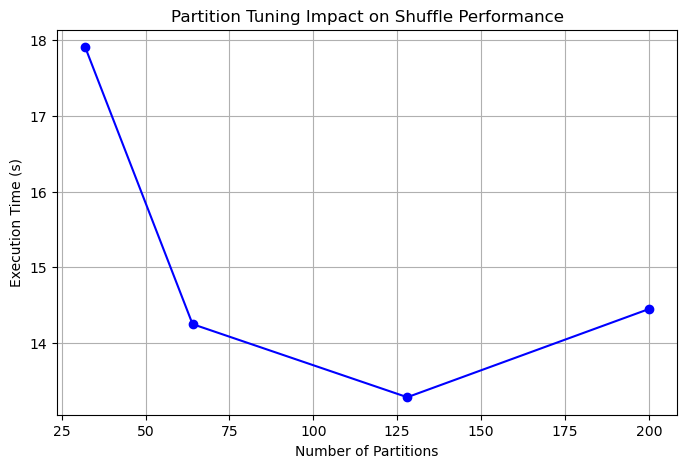

In [10]:
plt.figure(figsize=(8,5))
plt.plot(partitions, times, marker='o', color='blue')
plt.xlabel("Number of Partitions")
plt.ylabel("Execution Time (s)")
plt.title("Partition Tuning Impact on Shuffle Performance")
plt.grid(True)
plt.show()